# Parameter reconstruction precision & Signal disappearance

In [2]:
#########################################################
# Example script for plotting the parameter reconstruction precision and the signal disappearance
# by running or recalling prior results from respectively Parameters_Precision.py and/or Signal_Disappearance.py
#########################################################

The scripts Parameters_Precision.py and Signal_Disappearance.py are recalled to compute the parameter reconstruction precision and its lack of signal in case of disappearance, by setting all GW parameters except the masses $M_1$ and $M_2$ of the WDB, which are varied. Results are stored in, and eventually recalled from, Precision_Output folder.

Precision on mass ratio $q$, chirp mass $\mathcal{M}_c$, luminosity distance $d_L$ and sky localisation $\Omega$ are plotted.

The time necessary to reach an SNR of 1 after RLOF, which represent the minimal time necessary for recognising if a WDB is still there or not, is also plotted.

## Initial Settings

### Packages

In [3]:
import pickle
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.colors as colors

from Analysis_Scripts import constants as const
from Analysis_Scripts import waveform_LO
from Analysis_Scripts import WD
from Analysis_Scripts import plot_format as formatter

import Signal_Disappearance
import Parameters_Precision 


/home/giona/.local/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


### Set GW input

In [4]:
######################################################
# set parameters
### These parameters can be changed in order to evaluate the signal of various sources

minMass=0.4
maxMass=WD.maxWDMass*0.95

run_type = 'M1M2' # "M1M2" or "McdL" # Type of evaluation
selected_SNR = 1 # minimum SNR to reach to consider the signal as disappeard
rangelength = 30 # number of bins in the chosen grid axes

source_dL = 25. # luminosity distance [Mpc]
source_tau0= 0. #decided to be the same as coalescence time
source_tc = 0. # time of merger, measured from the solar equinox [seconds]
source_phi0 = 0. # [0,2*np.pi] phase of the GW signal at fGWmin
source_iota = np.pi/4. # [0,np.pi]angle between sky localization and orbital momentum of the binary [rad]
source_psi = np.pi*3/4. # [0,2*np.pi]polarization angle [rad]
source_RA = np.pi # [0,2*np.pi]source right ascesnsion [rad], max at np.pi/2 for other values maximised
source_DEC_title = -np.pi/6. # [-np.pi/2,np.pi/2] source declination [rad], max at np.pi/2
source_DEC = source_DEC_title - np.pi*23.4/180
duration=1.

#These two variables are needed for running the code but irrelevant for M1M2 computations
source_Mc = 0.75 # detector-frame chirp mass [Msol]])
source_q = 1.05 # mass ratio (m_1/m_2)

# Set the range of masses to be evaluated and plotted for both computations (Parameters_Precision and Signal_Disappearance)
M=np.linspace(minMass,maxMass,rangelength)

## Run/Recall data 

### Parameter reconstruction precision

#### Initialise the parameter reconstruction Class

In [5]:
# Initialize the code for computing the parameters precision

Param_Precision = Parameters_Precision.Precisions(      
                # Settings for the the disappearance
                 run_type,# "M1M2" or "McdL" # Type of evaluation
                 rangelength, # number of bins in the chosen grid axes
                 #######################
                 # GW source
                 source_Mc, # detector-frame chirp mass [Msol]])
                 source_q, # mass ratio (m_1/m_2)
                 source_dL, # luminosity distance [Mpc]
                 source_tau0, #decided to be the same as coalescence time
                 source_tc, # time of merger, measured from the solar equinox [seconds]
                 source_phi0, # [0,2*np.pi] phase of the GW signal at fGWmin
                 source_iota, # [0,np.pi]angle between sky localization and orbital momentum of the binary [rad]
                 source_psi, # [0,2*np.pi]polarization angle [rad]
                 source_RA, # [0,2*np.pi]source right ascesnsion [rad], max at np.pi/2 for other values maximised
                 source_DEC_title, # [-np.pi/2,np.pi/2] source declination [rad], max at np.pi/2)
                #######################
                 # Setting on the ranges to explore
                 minMass=minMass,
                 maxMass=maxMass,
                 duration=duration
                 )      


#### Run parameter reconstruction

If the same run has already been run, the script recognises it and does not run it again

In [6]:
# Check that the information you want to plot have been computed, or compute them
Param_Precision.run()

# If you want to double check that all parameters match with your entry, check the info_ file


Computation for  M1M2  case

Computation at PN order: 3.5 and 3.0

25  source_dL [Mpc]
0.785  source_iota [rad]
0  source_phi0 [rad]
0  source_tc [s] 
3.14  source_RA [rad]
-0.524  source_DEC [rad] (compared to Earth equator)
2.36  source_psi [rad]

1.57  detector_RA [rad]
-0.408  detector_DEC [rad]

Computation was previously already done.


If the run is required, many output are given. These simply represent the steps of the $M_1$-$M_2$ grid that are not computed because they do not represent WDB or fall off the sensitivity of the instrument of interest.

#### Recall and reorganize output data in an easy way to plot

From the Fisher matrix, the precision on on mass ratio $q$, chirp mass $\mathcal{M}_c$, luminosity distance $d_L$ and angles $\alpha$ and $\delta$ is recovered

In [7]:
#######################
filename = Param_Precision.filename

# set up path to store results
fpath_out = "Precision_Output/"+filename

SNR=np.full((rangelength,rangelength),np.nan)

precision_Mc=np.full((rangelength,rangelength),np.nan)
precision_q=np.full((rangelength,rangelength),np.nan)
precision_dL=np.full((rangelength,rangelength),np.nan)
precision_alpha=np.full((rangelength,rangelength),np.nan)
precision_delta=np.full((rangelength,rangelength),np.nan)

covariance_alphadelta=np.full((rangelength,rangelength),np.nan)
params_list = []

for i in range(rangelength):
    j=0
    while j<=i:
        source_McM1M2 = waveform_LO.Mc(M[i],M[j])# detector-frame chirp mass [Msol]])
        source_qM1M2 = M[i]/M[j]
        try:
            with open(fpath_out+f'classdata/dataM1{M[i]:.2f}M2{M[j]:.2f}.pkl', 'rb') as inp:
                results=pickle.load(inp)     
                FisherMatrix=np.copy(results.FisherMat)
                SNR[j,i]=np.sqrt(results.SNR2)
                CoVaMat_priors = np.linalg.inv(
                    np.double(FisherMatrix + results.PriorMat))
                precision_Mc[j,i]=np.sqrt(CoVaMat_priors[0,0])
                precision_q[j,i]=np.sqrt(CoVaMat_priors[1,1])
                precision_dL[j,i]=np.sqrt(CoVaMat_priors[5,5])
                precision_alpha[j,i]=np.sqrt(CoVaMat_priors[6,6])
                precision_delta[j,i]=np.sqrt(CoVaMat_priors[7,7])
            
                covariance_alphadelta[j,i]=CoVaMat_priors[6,7]
                j+=1
        except:
            j+=1
            continue

Xmass,Ymass=np.meshgrid(M,M)

RLOFfrequency_plot=np.where(Xmass>=Ymass, WD.WD_RLOFCutoffFrequency(Xmass,Ymass), np.nan)

### Signal Disappearance

#### Initialise the signal disappearance Class

In [8]:
# Initialize the code for computing the SNR disappearance

SNR_disappearance = Signal_Disappearance.Disappearance(      
                # Settings for the the disappearance
                 run_type,# "M1M2" or "McdL" # Type of evaluation
                 selected_SNR, # minimum SNR to reach to consider the signal as disappeared
                 rangelength, # number of bins in the chosen grid axes
                 #######################
                 # GW source
                 source_Mc, # detector-frame chirp mass [Msol]])
                 source_q, # mass ratio (m_1/m_2)
                 source_dL, # luminosity distance [Mpc]
                 source_tau0, #decided to be the same as coalescence time
                 source_tc, # time of merger, measured from the solar equinox [seconds]
                 source_phi0, # [0,2*np.pi] phase of the GW signal at fGWmin
                 source_iota, # [0,np.pi]angle between sky localization and orbital momentum of the binary [rad]
                 source_psi, # [0,2*np.pi]polarization angle [rad]
                 source_RA, # [0,2*np.pi]source right ascesnsion [rad], max at np.pi/2 for other values maximised
                 source_DEC_title, # [-np.pi/2,np.pi/2] source declination [rad], max at np.pi/2)
                #######################
                 # Setting on the ranges to explore
                 minMass=minMass,
                 maxMass=maxMass,
                 duration=duration
                 )      


#### Run signal disappearance

If the same run has already been run, the script recognises it and does not run it again

In [9]:
# Check that the information you want to plot have been computed, or compute them
SNR_disappearance.run()

# If you want to double check that all parameters match with your entry, check the info_ file


Computation for  M1M2  case

Computation at PN order: 3.5 and 3.0

25  source_dL [Mpc]
0.785  source_iota [rad]
0  source_phi0 [rad]
0  source_tc [s] 
3.14  source_RA [rad]
-0.524  source_DEC [rad] (compared to Earth equator)
2.36  source_psi [rad]

1.57  detector_RA [rad]
-0.408  detector_DEC [rad]

Computation was previously already done.


If the run is required, many output are given. These simply represent the steps of the $M_1$-$M_2$ grid that are not computed because they do not represent WDB or fall off the sensitivity of the instrument of interest.

#### Recall the saved signal disappearance times for the storage file

In [10]:
#######################
filename= Param_Precision.filename

# set up path to store results
fpath_out = "Precision_Output/"+filename

# set up path to store results
# Load the lists
with open(fpath_out+ "Signal_to_SNR_after_RLOF.pkl", "rb") as f:
    M1_signal, M2_signal, Signal_toSNR_after_RLOF = pickle.load(f)  # Unpack directly

## Plots

### Mass ratio $q$ & Chirp mass $\mathcal{M}_c$

#### Plot preparation

Axis, colorbar and ticks definition

In [11]:
# Preparation

plot_tmin_Mc = 10**(1/2)*1e-7
plot_tmax_Mc = 10**(3/4)*1e-6

min_plot_Mc=min(plot_tmin_Mc/10,np.nanmin(precision_Mc))
max_plot_Mc=max(plot_tmax_Mc*10,np.nanmax(precision_Mc))

ticks_Mc = np.geomspace(plot_tmin_Mc,plot_tmax_Mc,6)
tick_Mc_step=np.log10(ticks_Mc[1]/ticks_Mc[0])
bottom_tick_Mc=10**(np.log10(ticks_Mc[0])-tick_Mc_step)
top_tick_Mc=10**(np.log10(ticks_Mc[-1])+tick_Mc_step)

tick_labels_Mc=[formatter.scientific_formatter1(x,1) for x in ticks_Mc]


ticks_Mc = np.insert(ticks_Mc, 0, min_plot_Mc)
tick_labels_Mc.insert(0, '')
tick_labels_Mc[1] = f'$<${formatter.scientific_formatter1(plot_tmin_Mc,1)}'

norm_Mc = colors.BoundaryNorm(boundaries=ticks_Mc, ncolors=256)


plot_tmin_q = 10**(2/3)*1e-2
plot_tmax_q = 1e1

min_plot_q=min(plot_tmin_q/10,np.nanmin(precision_q))
max_plot_q=max(plot_tmax_q*10,np.nanmax(precision_q))

ticks_q = np.geomspace(plot_tmin_q,plot_tmax_q,8)
tick_q_step=np.log10(ticks_q[1]/ticks_q[0])
bottom_tick_q=10**(np.log10(ticks_q[0])-tick_q_step)
top_tick_q=10**(np.log10(ticks_q[-1])+tick_q_step)
tick_labels_q=[formatter.scientific_formatter(x,1) for x in ticks_q]

ticks_q = np.append(ticks_q, max_plot_q)
tick_labels_q.append('')
tick_labels_q[-2] = f'$>${formatter.scientific_formatter(plot_tmax_q,1)}'


norm_q = colors.BoundaryNorm(boundaries=ticks_q, ncolors=256)

print(ticks_q,tick_labels_q)
print(precision_q)

[4.64158883e-02 1.00000000e-01 2.15443469e-01 4.64158883e-01
 1.00000000e+00 2.15443469e+00 4.64158883e+00 1.00000000e+01
 4.55399534e+02] ['', '$10^{-1}$', '', '', '$1$', '', '', '$>$$10^{1}$', '']
[[           nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan]
 [           nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan            nan            nan            nan
             nan        

#### Plotting

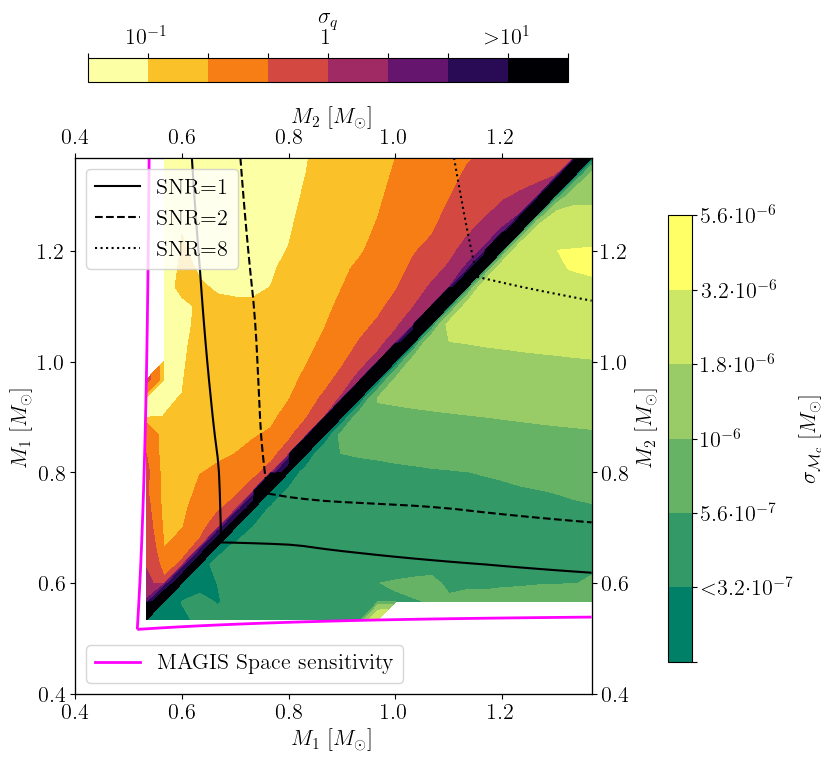

In [12]:
title='Precision measurement on '+r'$\mathcal{M}_c$ and $q$'

scalingy=8/8
scalingx=8.6/8
figMcq = plt.figure(figsize=(8*scalingx,8*scalingy))
fig_ax = figMcq.add_subplot(111)

figMcq.subplots_adjust(right=0.78/scalingx, top=0.78/scalingy)
# plt.suptitle(title, fontsize=20,y=0.99)


fig_Mc = fig_ax.twinx()

#Plot frequency in the bottom right part of the plot
fig_Mc_contour = fig_Mc.contourf(M, M, precision_Mc, levels=ticks_Mc, norm=norm_Mc, cmap='summer')
#Add colorbar, manually positioned
fig_Mc_cax = figMcq.add_axes([.875/scalingx, 0.15/scalingy, 0.03/scalingx, 0.6/scalingx])
fig_Mc_bar = plt.colorbar(fig_Mc_contour,label=r"$\sigma_{\mathcal{M}_c}$ [$M_\odot$]", orientation='vertical', cax=fig_Mc_cax)
fig_Mc_bar.ax.yaxis.label.set_size(16) 
fig_Mc_bar.ax.tick_params(labelsize=16)
fig_Mc_bar.set_ticks(ticks_Mc)
fig_Mc_bar.set_ticklabels(tick_labels_Mc) 

fig_q = fig_ax.twiny()
#Plot frequency in the bottom right part of the plot
fig_q_contour = fig_q.contourf(M, M, precision_q.T, levels=ticks_q, norm=norm_q, cmap=plt.cm.inferno.reversed())

#Add colorbar, manually positioned
fig_q_cax = figMcq.add_axes([0.15/scalingx, .875/scalingy, 0.6/scalingx, 0.03/scalingy])
fig_q_bar = plt.colorbar(fig_q_contour,label=r"$\sigma_{q}$ ", orientation='horizontal', cax=fig_q_cax)
fig_q_bar.ax.xaxis.set_label_position('top')
fig_q_bar.ax.xaxis.set_ticks_position('top')
fig_q_bar.ax.xaxis.label.set_size(16) 
fig_q_bar.ax.tick_params(labelsize=16)
fig_q_bar.set_ticks(ticks_q)
fig_q_bar.set_ticklabels(tick_labels_q) 

fig_ax.set_ylabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
fig_q.set_xlabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)
fig_ax.set_xlabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
fig_Mc.set_ylabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)

fig_ax.xaxis.set_tick_params(labelsize=16)
fig_ax.yaxis.set_tick_params(labelsize=16)
fig_q.xaxis.set_tick_params(labelsize=16)
fig_Mc.yaxis.set_tick_params(labelsize=16)

lower_limit=0.4
fig_ax.set_xlim(left=lower_limit)
fig_ax.set_ylim(bottom=lower_limit)
fig_q.set_xlim(left=lower_limit)
fig_q.set_ylim(bottom=lower_limit)
fig_Mc.set_xlim(left=lower_limit)
fig_Mc.set_ylim(bottom=lower_limit)

#Plot detector limit contour
fig_q.contour(M,M,RLOFfrequency_plot, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
fig_q.contour(M,M,RLOFfrequency_plot.T, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
proxy_Detector = plt.Line2D([0], [0], color='magenta', linestyle='solid',linewidth=2)

fig_q.contour(M, M, SNR, levels=[1],colors="black",linestyles='-')
fig_q.contour(M, M, SNR.T, levels=[1],colors="black",linestyles='-')
proxy_SNR1 = plt.Line2D([0], [0], color='black', linestyle='-')
fig_q.contour(M, M, SNR, levels=[2],colors="black",linestyles='--')
fig_q.contour(M, M, SNR.T, levels=[2],colors="black",linestyles='--')
proxy_SNR2 = plt.Line2D([0], [0], color='black', linestyle='--')
fig_q.contour(M, M, SNR, levels=[8],colors="black",linestyles=':')
fig_q.contour(M, M, SNR.T, levels=[8],colors="black",linestyles=':')
proxy_SNR8 = plt.Line2D([0], [0], color='black', linestyle=':')

first_legend = fig_q.legend([proxy_Detector],
           ["MAGIS Space sensitivity"],
            fontsize=16,loc="lower left")

# Create another legend for the next three lines (three entries)
second_legend = fig_q.legend([proxy_SNR1,proxy_SNR2,proxy_SNR8],
           ["SNR=1",'SNR=2','SNR=8'],
            fontsize=16,loc="upper left")

# Add both legends to the plot
fig_q.add_artist(first_legend)

plt.savefig(fpath_out+'Precision_q_Mc.pdf')
plt.show() 

### Luminosity distance $d_L$ & Sky localisation $\Omega$

#### Sky localisation precision computation

In [13]:
# # Sky Localization Precision
precision_Sky=2*np.pi*np.cos(source_DEC)*np.sqrt(precision_alpha**2*precision_delta**2-covariance_alphadelta**2)*(180/np.pi)**2

#### Plot preparation

Axis, colorbar and ticks definition

In [14]:
# Preparation


plot_tmin_Sky = 1e-3
plot_tmax_Sky = 100

min_plot_Sky=min(plot_tmin_Sky/10,np.nanmin(precision_Sky))
max_plot_Sky=max(plot_tmax_Sky,np.nanmax(precision_Sky))

ticks_Sky = np.geomspace(plot_tmin_Sky,plot_tmax_Sky,round(np.log10(plot_tmax_Sky/plot_tmin_Sky))+1)
tick_labels_Sky=[formatter.scientific_formatter(x,1) for x in ticks_Sky]

tick_labels_Sky[-1] = f'{formatter.scientific_formatter(plot_tmax_Sky,1)}'
norm_Sky = colors.BoundaryNorm(boundaries=ticks_Sky, ncolors=256)


plot_tmin_dL = 10**(1/2)
plot_tmax_dL = 10**(1/4)*1e2

min_plot_dL=min(plot_tmin_dL/10,np.nanmin(precision_dL))
max_plot_dL=max(plot_tmax_dL*10,np.nanmax(precision_dL))

ticks_dL = np.geomspace(plot_tmin_dL,plot_tmax_dL,8)
tick_labels_dL=[formatter.scientific_formatter(x,1) for x in ticks_dL]

tick_labels_dL[0] = f'{formatter.scientific_formatter1(plot_tmin_dL,1)}'

norm_dL = colors.BoundaryNorm(boundaries=ticks_dL, ncolors=256)

#### Plotting

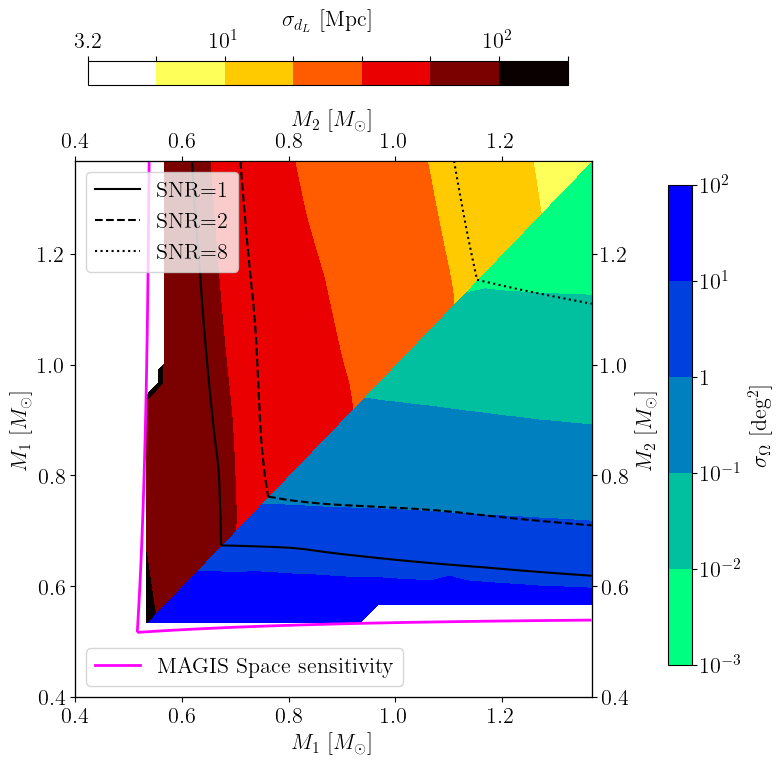

In [15]:

title='Precision measurement on sky localization and $d_L$'

scalingy=8/8
scalingx=8.6/8
figSkydL = plt.figure(figsize=(8*scalingx,8*scalingy))
fig_ax = figSkydL.add_subplot(111)

figSkydL.subplots_adjust(right=0.78/scalingx, top=0.78/scalingy)
# plt.suptitle(title, fontsize=20,y=0.99)


fig_Sky = fig_ax.twinx()
#Plot frequency in the bottom right part of the plot
fig_Sky_contour = fig_Sky.contourf(M, M, precision_Sky, levels=ticks_Sky, norm=norm_Sky, cmap=plt.cm.winter.reversed())
#Add colorbar, manually positioned
fig_Sky_cax = figSkydL.add_axes([.875/scalingx, 0.15/scalingy, 0.03/scalingx, 0.6/scalingy])
fig_Sky_bar = plt.colorbar(fig_Sky_contour,label=r"$\sigma_{\Omega}$ [deg$^2$]", orientation='vertical', cax=fig_Sky_cax)
fig_Sky_bar.ax.yaxis.label.set_size(16) 
fig_Sky_bar.ax.tick_params(labelsize=16)
fig_Sky_bar.set_ticks(ticks_Sky)
fig_Sky_bar.set_ticklabels(tick_labels_Sky) 

fig_dL = fig_ax.twiny()
#Plot frequency in the bottom right part of the plot
fig_dL_contour = fig_dL.contourf(M, M, precision_dL.T, levels=ticks_dL, norm=norm_dL,cmap=plt.cm.hot.reversed())
#Add colorbar, manually positioned
fig_dL_cax = figSkydL.add_axes([0.15/scalingx, .875/scalingy, 0.6/scalingx, 0.03/scalingy])
fig_dL_bar = plt.colorbar(fig_dL_contour,label=r"$\sigma_{d_L}$ [Mpc]", orientation='horizontal', cax=fig_dL_cax)
fig_dL_bar.ax.xaxis.set_label_position('top')
fig_dL_bar.ax.xaxis.set_ticks_position('top')
fig_dL_bar.ax.xaxis.label.set_size(16) 
fig_dL_bar.ax.tick_params(labelsize=16)
fig_dL_bar.set_ticks(ticks_dL)
fig_dL_bar.set_ticklabels(tick_labels_dL) 

fig_ax.set_ylabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
fig_dL.set_xlabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)
fig_ax.set_xlabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
fig_Sky.set_ylabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)

fig_ax.xaxis.set_tick_params(labelsize=16)
fig_ax.yaxis.set_tick_params(labelsize=16)
fig_dL.xaxis.set_tick_params(labelsize=16)
fig_Sky.yaxis.set_tick_params(labelsize=16)

lower_limit=0.4
fig_ax.set_xlim(left=lower_limit)
fig_ax.set_ylim(bottom=lower_limit)
fig_dL.set_xlim(left=lower_limit)
fig_dL.set_ylim(bottom=lower_limit)
fig_Sky.set_xlim(left=lower_limit)
fig_Sky.set_ylim(bottom=lower_limit)

#Plot detector limit contour
fig_dL.contour(M,M,RLOFfrequency_plot, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
fig_dL.contour(M,M,RLOFfrequency_plot.T, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
proxy_Detector = plt.Line2D([0], [0], color='magenta', linestyle='solid',linewidth=2)

fig_dL.contour(M, M, SNR, levels=[1],colors="black",linestyles='-')
fig_dL.contour(M, M, SNR.T, levels=[1],colors="black",linestyles='-')
proxy_SNR1 = plt.Line2D([0], [0], color='black', linestyle='-')
fig_dL.contour(M, M, SNR, levels=[2],colors="black",linestyles='--')
fig_dL.contour(M, M, SNR.T, levels=[2],colors="black",linestyles='--')
proxy_SNR2 = plt.Line2D([0], [0], color='black', linestyle='--')
fig_dL.contour(M, M, SNR, levels=[8],colors="black",linestyles=':')
fig_dL.contour(M, M, SNR.T, levels=[8],colors="black",linestyles=':')
proxy_SNR8 = plt.Line2D([0], [0], color='black', linestyle=':')

first_legend = fig_dL.legend([proxy_Detector],
           ["MAGIS Space sensitivity"],
            fontsize=16,loc="lower left")

# Create another legend for the next three lines (three entries)
second_legend = fig_dL.legend([proxy_SNR1,proxy_SNR2,proxy_SNR8],
           ["SNR=1",'SNR=2','SNR=8'],
            fontsize=16,loc="upper left")

# Add both legends to the plot
fig_dL.add_artist(first_legend)

plt.savefig(fpath_out+'Precision_dL_Sky.pdf')
plt.show() 

### Disappearance time

#### Plot preparation

Axis, colorbar and ticks definition.

The computation of the parameter precision, which also provides the SNR before RLOF, is need as it is plotted

In [16]:
# Preparation

Signal_toSNR_after_RLOF_year = Signal_toSNR_after_RLOF/ const.year # Plot time in years

plot_tmin_Signal = 1e-3
plot_tmax_Signal = 10

min_plot_Signal=min(plot_tmin_Signal/10,np.nanmin(Signal_toSNR_after_RLOF_year))
max_plot_Signal=max(plot_tmax_Signal*10,np.nanmax(Signal_toSNR_after_RLOF_year))

ticks_Signal = np.geomspace(plot_tmin_Signal,plot_tmax_Signal,round(np.log10(plot_tmax_Signal/plot_tmin_Signal))*2+1)
tick_labels_Signal=[formatter.scientific_formatter(x,1) for x in ticks_Signal]

ticks_Signal = np.append(ticks_Signal, max_plot_Signal)
tick_labels_Signal.append('')
tick_labels_Signal[-2] = f'$>${plot_tmax_Signal}'

norm_Signal = colors.BoundaryNorm(boundaries=ticks_Signal, ncolors=256)


plot_tmin_SNR = 0.1
plot_tmax_SNR = 100

min_plot_SNR=min(plot_tmin_SNR/10,np.nanmin(SNR))
max_plot_SNR=max(plot_tmax_SNR*10,np.nanmax(SNR))

ticks_SNR = np.geomspace(plot_tmin_SNR,plot_tmax_SNR,round(np.log10(plot_tmax_SNR/plot_tmin_SNR))*3+1)
tick_labels_SNR=[formatter.scientific_formatter(x,1) for x in ticks_SNR]

norm_SNR = colors.BoundaryNorm(boundaries=ticks_SNR, ncolors=256)

#### Plotting

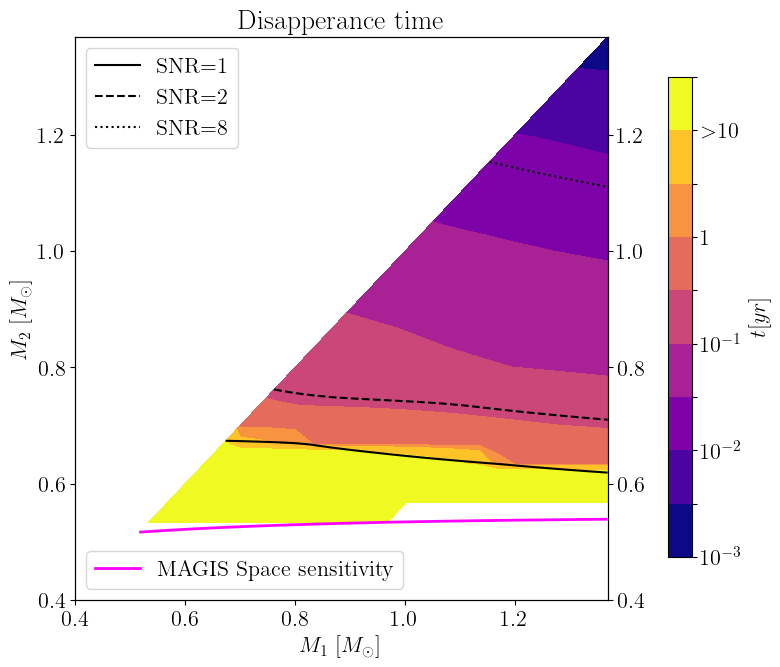

In [17]:
title='Disapperance time'

scalingy=7/8
scalingx=8.6/8
figSignalSNR = plt.figure(figsize=(8*scalingx,8*scalingy))
fig_ax = figSignalSNR.add_subplot(111)


figSignalSNR.subplots_adjust(right=0.8/scalingx, top=0.8/scalingy)
plt.title(title, fontsize=20)


# fig_Signal = fig_ax.twinx()
#Plot frequency in the bottom right part of the plot
fig_Signal_contour = fig_ax.contourf(M1_signal, M2_signal, Signal_toSNR_after_RLOF_year, levels=ticks_Signal, norm=norm_Signal, cmap='plasma')
#Add colorbar, manually positioned
fig_Signal_cax = figSignalSNR.add_axes([.875/scalingx, 0.15/scalingy, 0.03/scalingx, 0.6/scalingy])
fig_Signal_bar = plt.colorbar(fig_Signal_contour,label=r"$t [yr]$", orientation='vertical', cax=fig_Signal_cax)
fig_Signal_bar.ax.yaxis.label.set_size(16) 
fig_Signal_bar.ax.tick_params(labelsize=16)
fig_Signal_bar.set_ticks(ticks_Signal)
fig_Signal_bar.set_ticklabels(tick_labels_Signal) 


fig_ax.set_xlabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)

fig_ax.set_ylabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)

lower_limit=0.4
fig_ax.set_xlim(left=lower_limit)
fig_ax.set_ylim(bottom=lower_limit)

fig_ax.xaxis.set_tick_params(labelsize=16)
fig_ax.yaxis.set_tick_params(labelsize=16)

fig_ticks_left = fig_ax.twinx()
fig_ticks_left.yaxis.set_tick_params(labelsize=16)
fig_ticks_left.set_ylim(bottom=lower_limit)
fig_ticks_left.set_ylim(top=np.max(M2_signal))

#Plot detector limit contour
fig_ax.contour(M,M,RLOFfrequency_plot, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
proxy_Detector = plt.Line2D([0], [0], color='magenta', linestyle='solid',linewidth=2)

fig_ax.contour(M, M, SNR, levels=[1],colors="black",linestyles='-')
proxy_SNR1 = plt.Line2D([0], [0], color='black', linestyle='-')
fig_ax.contour(M, M, SNR, levels=[2],colors="black",linestyles='--')
proxy_SNR2 = plt.Line2D([0], [0], color='black', linestyle='--')
fig_ax.contour(M, M, SNR, levels=[8],colors="black",linestyles=':')
proxy_SNR8 = plt.Line2D([0], [0], color='black', linestyle=':')

first_legend = fig_ax.legend([proxy_Detector],
           ["MAGIS Space sensitivity"],
            fontsize=16,loc="lower left")

# Create another legend for the next three lines (three entries)
second_legend = fig_ax.legend([proxy_SNR1,proxy_SNR2,proxy_SNR8],
           ["SNR=1",'SNR=2','SNR=8'],
            fontsize=16,loc="upper left")

# Add both legends to the plot
fig_ax.add_artist(first_legend)

plt.savefig(fpath_out+'Precision_SNR_Signal.pdf')
plt.show() 

End